# Machine Learning Model Execution

This notebook demonstrates how to build, train and evaluate a machine learning model using Python.

# Import Required Libraries

Import libraries such as pandas, numpy, scikit-learn, and matplotlib for data handling, model training, and evaluation.

In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set plot style
sns.set(font_scale=1.2)

# For reproducibility
np.random.seed(42)

# Load and Prepare Dataset

Load a dataset using pandas, clean it if necessary, and prepare it for training by selecting features and target variables.

In [4]:
# For this example, we'll use the Iris dataset from scikit-learn
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['target'] = y
iris_df['target_names'] = iris_df['target'].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

# Display the first few rows of the dataset
print("Dataset shape:", iris_df.shape)
iris_df.head()

Dataset shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
# Check for missing values
print("Missing values per column:")
print(iris_df.isnull().sum())

# Display basic statistics
print("\nBasic statistics:")
iris_df.describe()

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_names         0
dtype: int64

Basic statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


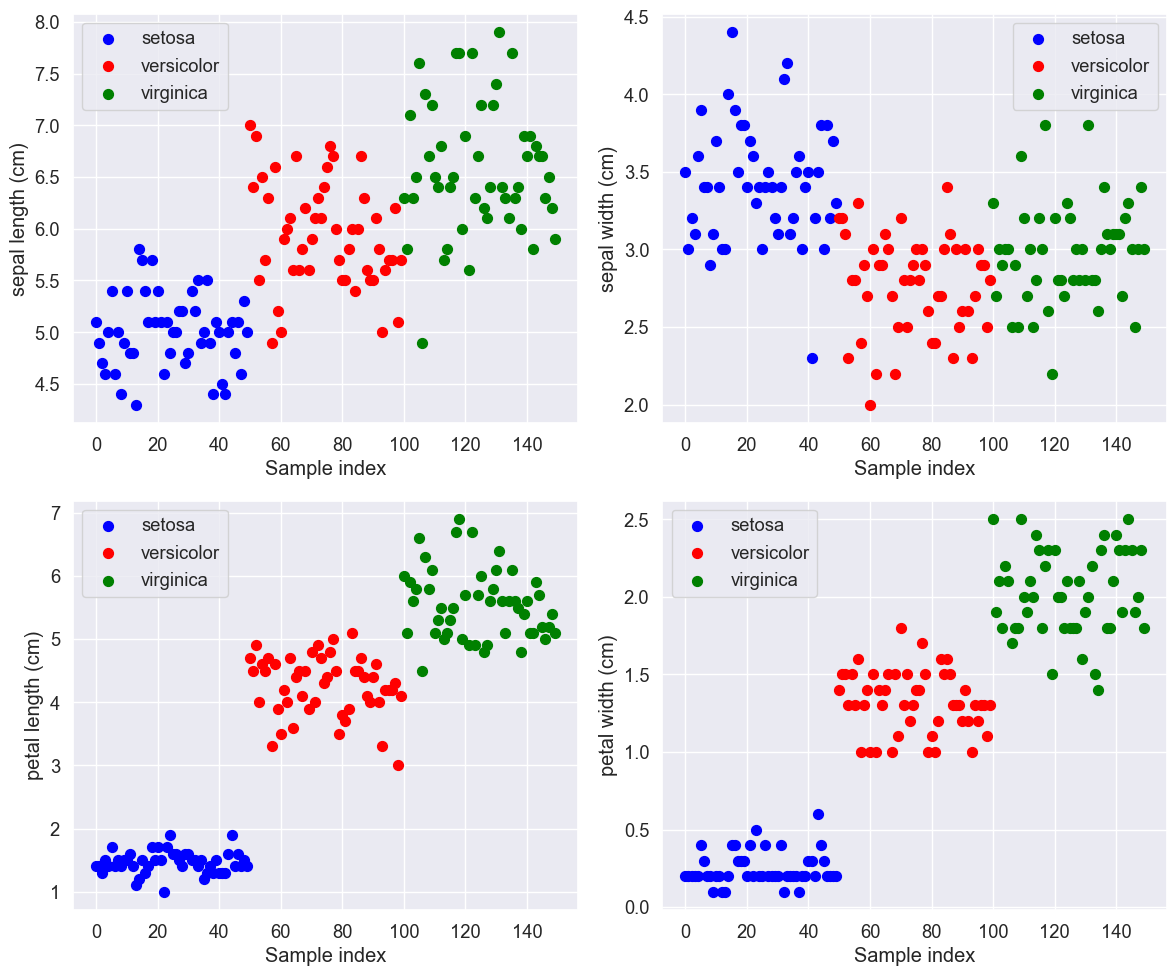

In [6]:
# Visualize the distribution of features
plt.figure(figsize=(12, 10))

for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i+1)
    for target, color in zip(range(3), ['blue', 'red', 'green']):
        plt.scatter(
            iris_df[iris_df['target'] == target].index,
            iris_df[iris_df['target'] == target][feature],
            c=color,
            s=50,
            label=iris.target_names[target]
        )
    plt.xlabel('Sample index')
    plt.ylabel(feature)
    plt.legend()

plt.tight_layout()
plt.show()

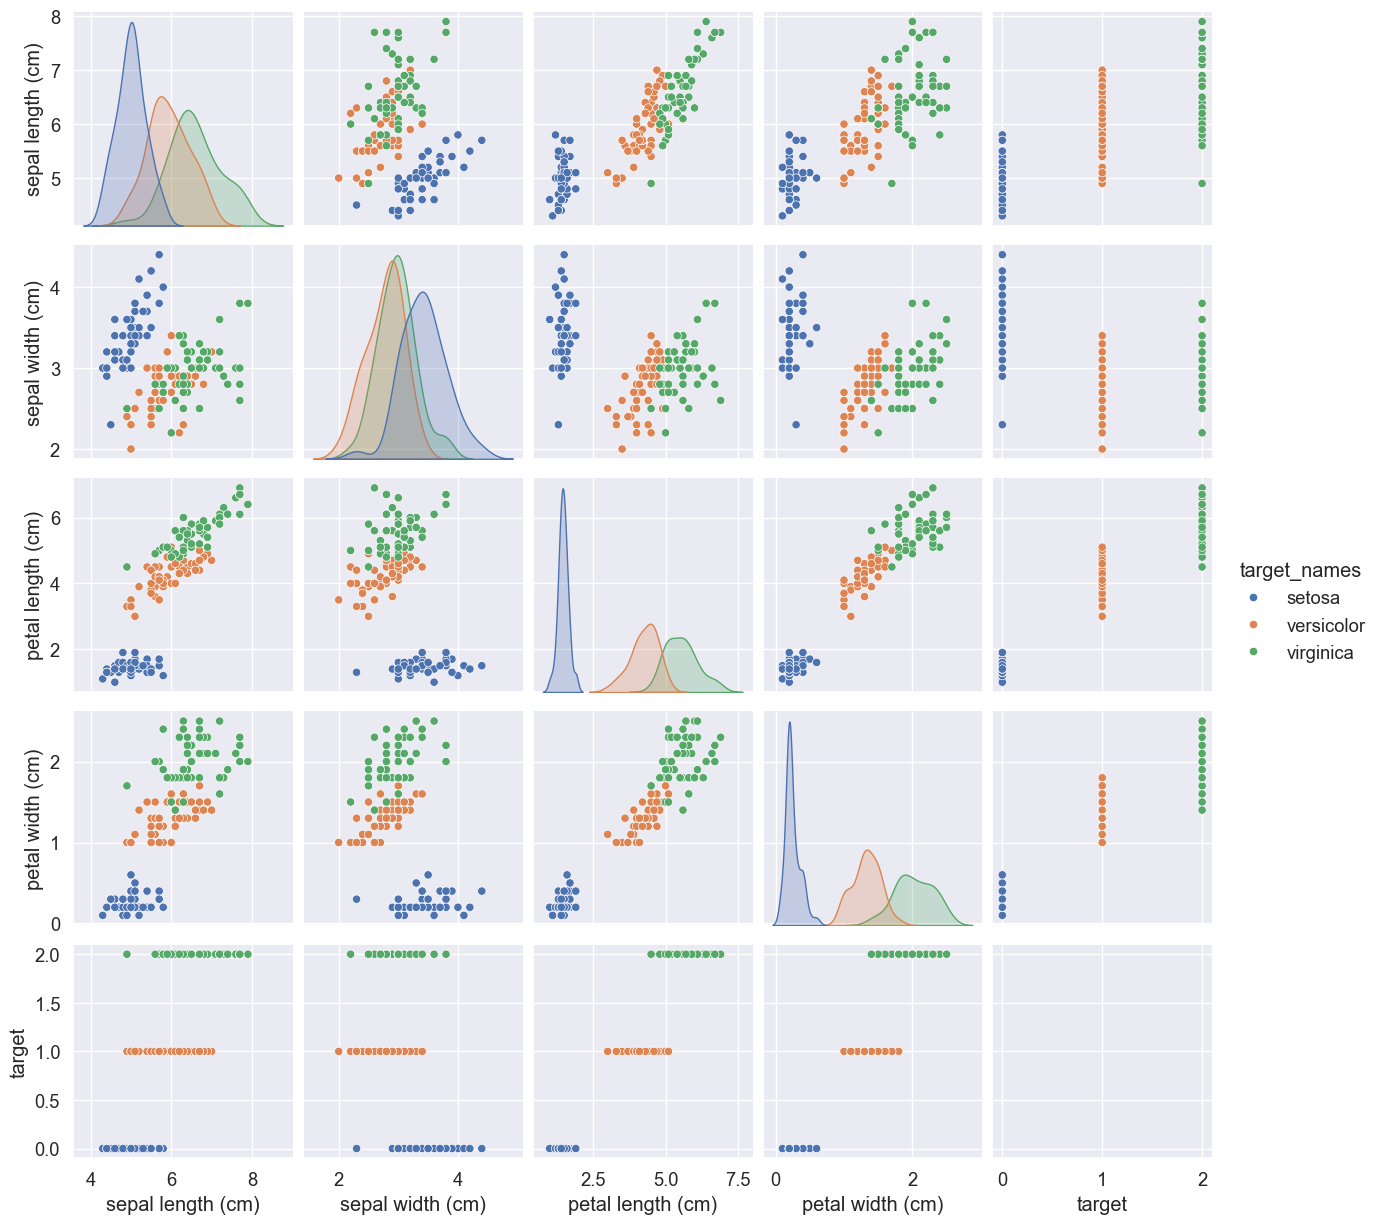

In [7]:
# Pairplot to visualize relationships between features
sns.pairplot(iris_df, hue='target_names', height=2.5)
plt.show()

# Split Dataset into Training and Testing Sets

Use train_test_split from scikit-learn to split the dataset into training and testing sets.

In [8]:
# Split the data into features (X) and target variable (y)
X = iris_df.drop(['target', 'target_names'], axis=1)
y = iris_df['target']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the training and testing sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify the distribution of classes in the training and testing sets
print("\nClass distribution in the training set:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution in the testing set:")
print(pd.Series(y_test).value_counts())

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)

Class distribution in the training set:
target
0    40
2    40
1    40
Name: count, dtype: int64

Class distribution in the testing set:
target
0    10
2    10
1    10
Name: count, dtype: int64


In [9]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the first few rows of the scaled training set
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-1.721568,-0.332101,-1.345722,-1.323276
1,-1.124492,-1.227655,0.414505,0.651763
2,1.144395,-0.555990,0.584850,0.256755
3,-1.124492,0.115676,-1.288941,-1.454945
4,-0.408002,-1.227655,0.130598,0.125086


# Train a Machine Learning Model

Choose a machine learning model (e.g., Linear Regression, Decision Tree, etc.) from scikit-learn and train it using the training dataset.

In [10]:
# Define models to train
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Dictionary to store trained models
trained_models = {}

# Train each model and store them
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} training complete.")

print("\nAll models have been trained.")

Training Logistic Regression...
Logistic Regression training complete.
Training Decision Tree...
Decision Tree training complete.
Training Random Forest...
Random Forest training complete.

All models have been trained.


# Evaluate the Model

Evaluate the model's performance using metrics such as accuracy, precision, recall, or mean squared error, depending on the problem type.

Model: Logistic Regression
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



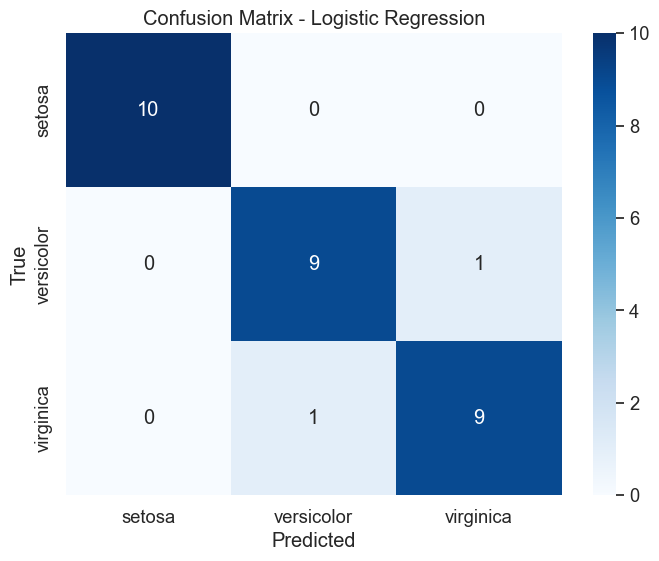

------------------------------------------------------------
Model: Decision Tree
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



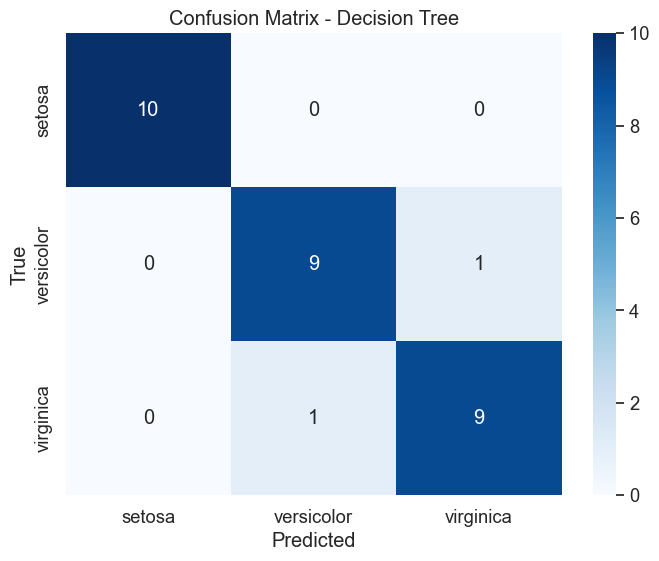

------------------------------------------------------------
Model: Random Forest
Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



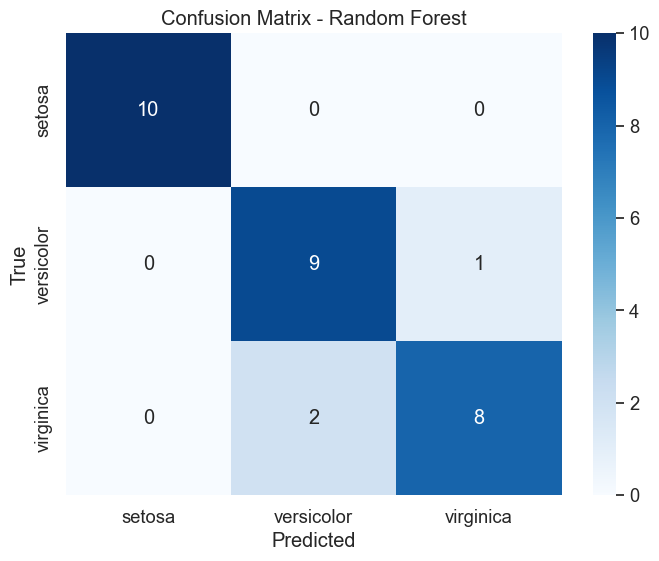

------------------------------------------------------------


In [11]:
# Function to evaluate and display model performance
def evaluate_model(model, X_test, y_test, model_name):
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Print results
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris.target_names, 
                yticklabels=iris.target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
# Evaluate each model
for name, model in trained_models.items():
    evaluate_model(model, X_test_scaled, y_test, name)
    print("-" * 60)

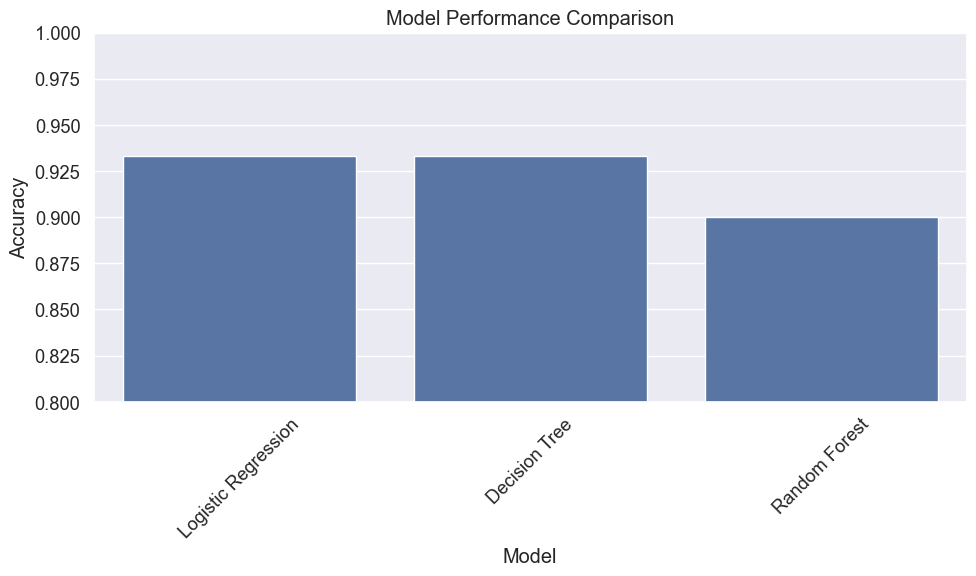

The best performing model is: Logistic Regression with an accuracy of 0.9333


In [12]:
# Compare models
model_scores = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    model_scores[name] = accuracy

# Create a bar chart to compare model performance
plt.figure(figsize=(10, 6))
sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()))
plt.ylim([0.8, 1.0])  # Adjusting y-axis for better visualization
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Find the best model
best_model = max(model_scores.items(), key=lambda x: x[1])
print(f"The best performing model is: {best_model[0]} with an accuracy of {best_model[1]:.4f}")

# Make Predictions

Use the trained model to make predictions on the test dataset and display the results.

In [13]:
# Get the best model
best_model_name = max(model_scores.items(), key=lambda x: x[1])[0]
best_model = trained_models[best_model_name]

# Make predictions on the test set
y_pred = best_model.predict(X_test_scaled)

# Create a DataFrame to display the predictions
results_df = pd.DataFrame({
    'Actual': [iris.target_names[i] for i in y_test],
    'Predicted': [iris.target_names[i] for i in y_pred]
})

# Sample from the results
print(f"Predictions using {best_model_name}:")
results_df.head(10)

Predictions using Logistic Regression:


,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


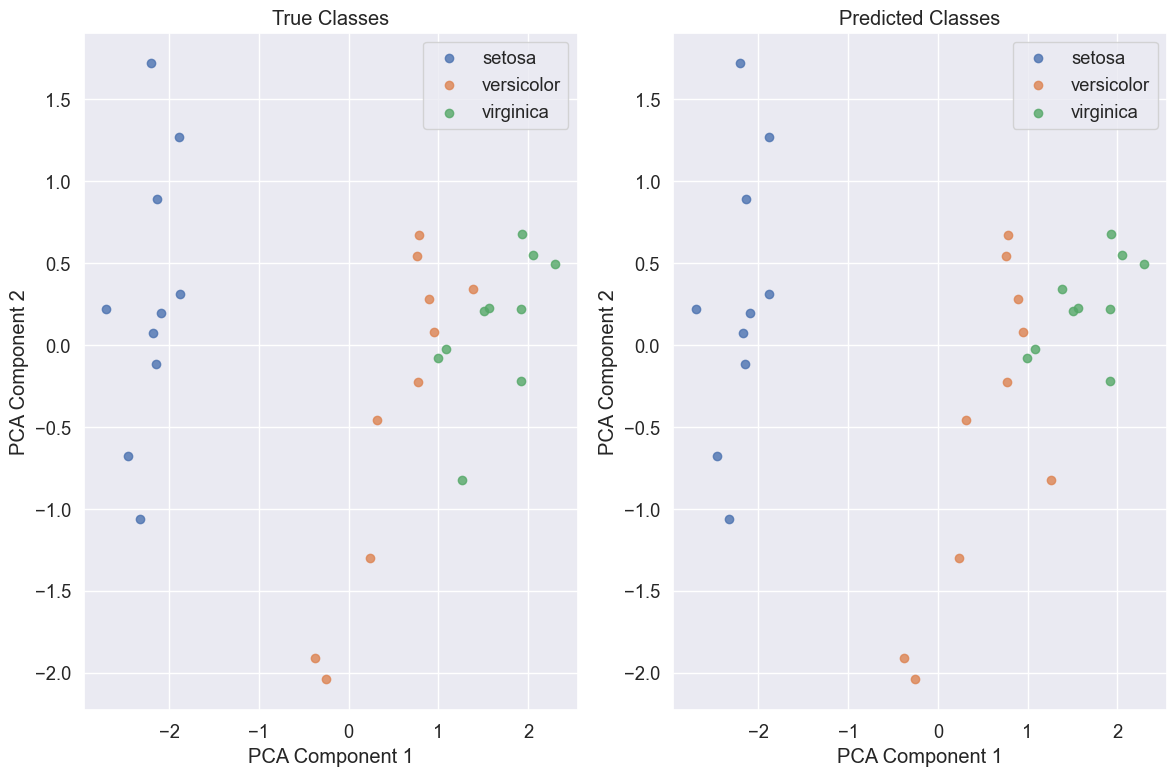

In [14]:
# Visualize prediction results on a scatter plot (only for 2D visualization)
# Let's use PCA to reduce the dimensions to 2 for visualization

from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

# Plot
plt.figure(figsize=(12, 8))

# Plot the true labels
plt.subplot(1, 2, 1)
for i, target_name in enumerate(iris.target_names):
    indices = y_test == i
    plt.scatter(X_test_pca[indices, 0], X_test_pca[indices, 1], 
                label=target_name, alpha=0.8)
plt.title('True Classes')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()

# Plot the predicted labels
plt.subplot(1, 2, 2)
for i, target_name in enumerate(iris.target_names):
    indices = y_pred == i
    plt.scatter(X_test_pca[indices, 0], X_test_pca[indices, 1], 
                label=target_name, alpha=0.8)
plt.title('Predicted Classes')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Make a new prediction with custom input
# Let's create a sample input data point

# Mean values for each feature from the dataset
sample_features = X.mean(axis=0).reshape(1, -1)

# Scale the features
sample_scaled = scaler.transform(sample_features)

# Make a prediction
prediction = best_model.predict(sample_scaled)
prediction_proba = best_model.predict_proba(sample_scaled)

print("Sample input (mean values of features):")
print(pd.DataFrame(sample_features, columns=iris.feature_names))
print("\nPredicted class:", iris.target_names[prediction[0]])
print("Prediction probabilities:")
for i, target_name in enumerate(iris.target_names):
    print(f"{target_name}: {prediction_proba[0][i]:.4f}")

AttributeError: 'Series' object has no attribute 'reshape'

## Conclusion

In this notebook, we:

1. Loaded and explored the Iris dataset
2. Prepared the data for machine learning by splitting it into training and testing sets
3. Trained multiple machine learning models (Logistic Regression, Decision Tree, and Random Forest)
4. Evaluated the models using accuracy metrics and confusion matrices
5. Made predictions with the best performing model
6. Visualized the results

This workflow can be applied to other datasets and different machine learning tasks by adjusting the preprocessing steps, model selection, and evaluation metrics based on the specific problem.